In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normalization(x):
 mu=np.mean(x,axis=0)
 stnd=np.std(x,axis=0)
 return mu,stnd

In [3]:
def compute_cost(x,y,w,b,m,lambda_,):  
 cost = 0.0
 f_wb= np.dot(x,w.T)+b
 cost = (((f_wb-y.T)**2).sum())/2
 cost+=(lambda_*((w**2).sum()))/2
 cost = cost/m
 return cost

In [4]:
def gradient_descent(x,y,w,b,alpha,itrns,lambda_):
 m,n=x.shape
 J_history=[]
 for i in range(itrns):
   dJ_dw=np.zeros((n,))
   dJ_db=0.
   f=(np.dot(x,w.T)+b)
   e=f-y
   dJ_dw=np.dot(e,x)+lambda_*w
   dJ_db=e.sum()
   dJ_dw=dJ_dw/m
   dJ_db=dJ_db/m
   w=w-alpha*dJ_dw
   b=b-alpha*dJ_db
   if i<10000:
     cost=compute_cost(x,y,w,b,m,lambda_)
     if i%(itrns/10)==0:
       print (f"Iteration {i}: Cost {cost}")
   J_history.append(cost)
 return w,b,cost,J_history

In [5]:
def R2Score(y,cost):
 rss=((y-np.mean(y))**2).sum()
 tss=cost*2*m
 r2s=1-tss/rss
 print(f"R2 Score: {r2s}")

Iteration 0: Cost 30125470437112.93
Iteration 1000: Cost 2855411456.2642612
Iteration 2000: Cost 785977138.0440122
Iteration 3000: Cost 362096857.381077
Iteration 4000: Cost 217073375.022922
Iteration 5000: Cost 149718121.4146875
Iteration 6000: Cost 113272657.20861712
Iteration 7000: Cost 91710958.3771911
Iteration 8000: Cost 77973535.28736338
Iteration 9000: Cost 68563967.26457636
w,b found by gradient descent for training set:[-5.24088292e+01 -7.81966984e+00 -2.79717176e+02 -3.84696110e+03
 -1.29721406e+03  1.35217162e+01 -4.91336854e+03 -7.49475650e+01
 -2.32570469e+02  6.72505427e+02 -2.80617249e+02 -3.09326193e+02
 -5.29372081e+00  7.58946013e+02 -7.44965646e+02 -2.75376312e+02
 -3.89775332e+02 -7.02813911e+02 -2.61061237e+02  4.05461662e+02
  2.80346174e+03 -1.90000094e+03 -2.03478688e+03  3.32410851e+02
  6.96814847e+03  5.46742548e+03 -3.10741364e+03 -9.84746601e+02
  9.86102855e+03  2.70011268e+03 -9.85363915e+02 -1.35678205e+03
 -6.64930057e+02 -7.60544761e+02 -1.86193913e+0

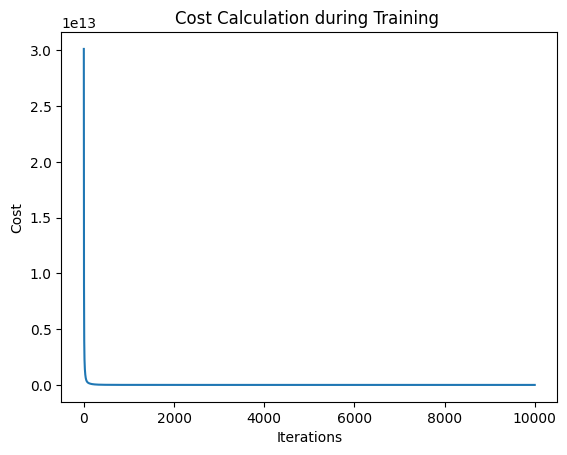

R2 Score for validation set : 
R2 Score: 0.9999981575819846
ID : 16588.0   cost: 560225.6397468721
ID : 17513.0   cost: 941558.2217952342
ID : 14448.0   cost: 15576.80169648159
ID : 13972.0   cost: 726923.9137503167
ID : 18321.0   cost: -167.28303979392405
ID : 19593.0   cost: 27401.03725578768
ID : 16569.0   cost: 66835.49613750762
ID : 11736.0   cost: 1394.9935529943946
ID : 18654.0   cost: 235.9559865742899
ID : 12539.0   cost: 115645.0189873154
ID : 19545.0   cost: 12724.480468541879
ID : 10113.0   cost: 1550431.7399796832
ID : 19387.0   cost: 979906.653587396
ID : 10985.0   cost: 94510.84837347045
ID : 18805.0   cost: 118939417.72623712
ID : 12993.0   cost: 47218.11462552944
ID : 17187.0   cost: 13874178.870159205
ID : 11290.0   cost: 416282.4955752428
ID : 12106.0   cost: 25214.430816274617
ID : 11139.0   cost: 193.4783094336506
ID : 15128.0   cost: 855.8123567508555
ID : 12377.0   cost: -481.6214620537022
ID : 14751.0   cost: -130.31601022471284
ID : 16358.0   cost: -280.8170266

In [6]:
 df=np.array(pd.read_csv("Polynomialdata_train.csv"))
 np.random.shuffle(df)
 x=df[:,1:]
 m,n = x.shape

 a=int(70/100*m)
 x_train=x[:a,:]
 mu,stnd=normalization(x_train)
 x_train=(x_train-mu)/stnd
 x_validate=x[a:,:]
 x_validate=(x_validate-mu)/stnd
 m,n=x_train.shape
 y=df[:,0]
 y_train=y[:a]
 y_validate=y[a:]
 w=np.random.randn(83,)
 b=np.random.rand()
 alpha=0.0001
 itrns=10000
 lambda_=10

 #x_train=np.c_[x_train.sum(axis=1),(x_train.sum(axis=1))**2,(x_train.sum(axis=1))**3,(x_train.sum(axis=1))**4,(x_train.sum(axis=1))**5]
 #x_validate=np.c_[x_validate.sum(axis=1),(x_validate.sum(axis=1))**2,(x_validate.sum(axis=1))**3,(x_validate.sum(axis=1))**4,(x_validate.sum(axis=1))**5]
 degree=6
 for d in range(1, degree + 1):
    for power_x in range(d + 1):
        for power_y in range(d - power_x + 1):
            power_z = d - power_x - power_y
            a = (x_train[:,0])**power_x
            b = (x_train[:,1])**power_y
            c = (x_train[:,2])**power_z
            prod=a*b*c
            count=0
            for i in range(x_train.shape[1]):
             if(np.any(prod==x_train[:,i])):
              count=count+1
            if count>0:
             continue
            x_train=np.c_[x_train,prod]
 w,b,cost,cost_history=gradient_descent(x_train,y_train,w,b,alpha,itrns,lambda_)
 print(f"w,b found by gradient descent for training set:{w}{b}")
 print(f"R2 Score for training set : ")
 R2Score(y_train,cost)

 plt.plot(cost_history)
 plt.xlabel('Iterations') 
 plt.ylabel('Cost' ) 
 plt.title('Cost Calculation during Training ' ) 
 plt.show()

 for d in range(1, degree + 1):
    for power_x in range(d + 1):
        for power_y in range(d - power_x + 1):
            power_z = d - power_x - power_y
            a = (x_validate[:,0])**power_x
            b = (x_validate[:,1])**power_y
            c = (x_validate[:,2])**power_z
            prod=a*b*c
            count=0
            for i in range(x_validate.shape[1]):
             if(np.any(prod==x_validate[:,i])):
              count=count+1
            if count>0:
             continue
            x_validate=np.c_[x_validate,prod]
 cost=compute_cost(x_validate,y_validate,w,b,m,lambda_)
 print(f"R2 Score for validation set : ")
 R2Score(y_validate,cost) 
 df1=np.array(pd.read_csv("Polynomialdata_test.csv"))
 x1=df1[:,1:]
 x1=(x1-mu)/stnd
 #x1=np.c_[x1.sum(axis=1),(x1.sum(axis=1))**2,(x1.sum(axis=1))**3,(x1.sum(axis=1))**4,(x1.sum(axis=1))**5]
 for d in range(1, degree + 1):
    for power_x in range(d + 1):
        for power_y in range(d - power_x + 1):
            power_z = d - power_x - power_y
            a = (x1[:,0])**power_x
            b = (x1[:,1])**power_y
            c = (x1[:,2])**power_z
            prod=a*b*c
            count=0
            for i in range(x1.shape[1]):
             if(np.any(prod==x1[:,i])):
              count=count+1
            if count>0:
             continue
            x1=np.c_[x1,prod]
 y1=np.dot(x1,w.T)+b
 Id=df1[:,0]
 for i in range(len(Id)):
  print(f"ID : {Id[i]}   cost: {y1.T[i]}")